In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


## import data and set some constants

In [2]:
data = pd.read_parquet('../data/data_full.parquet')
print(data.columns)
FLOAT_COLS = [
            'T',
            'ra',
            'dec',
            'u',
            'g',
            'r',
            'i',
            'z',
            'petroMag_r',
            'petroR50_r',
            'petroR90_r'
        ]
COLS_TO_DROP = [  # these columns are not physical, so they obviously will not relate to morphology
            '_RAJ2000',
            '_DEJ2000',
            'sidx',
            'petroR50_r',
            'petroR90_r',
            'petroMag_r',
            'u',
            'g',
            'r',
            'i',
            'z'
        ]

Index(['_RAJ2000', '_DEJ2000', 'T', 'sidx', 'objID', 'ra', 'dec', 'u', 'g',
       'r', 'i', 'z', 'petroMag_r', 'petroR50_r', 'petroR90_r'],
      dtype='object')


## convert columns to float

In [3]:
# cast some columns as float
for col in FLOAT_COLS:
    data[col] = pd.to_numeric(data[col], errors="coerce")

## data imputation

In [4]:
COLS_TO_IMPUTE = ['T', 'u', 'g', 'r', 'i', 'z', 'petroMag_r', 'petroR50_r', 'petroR90_r']

data['imputed_brightness'] = data['z'].isna().astype(int)
imputer = KNNImputer(n_neighbors=50, weights='uniform')
data[COLS_TO_IMPUTE] = imputer.fit_transform(data[COLS_TO_IMPUTE])

## derive some features

In [5]:
# calculate surface brightness
petroMag_r_half = data['petroMag_r'] + 0.7562
half_area_r = np.pi * data['petroR50_r']**2
data['sb50_r'] = petroMag_r_half + 2.512*np.log10(half_area_r)

# calculate surface brightness concentration
data['sb_conc_r'] = data['petroR90_r']/data['petroR50_r']

# calculate colors
data['ug_color'] = data['u'] - data['g']
data['ur_color'] = data['u'] - data['r']
data['ui_color'] = data['u'] - data['i']
data['uz_color'] = data['u'] - data['z']
data['gr_color'] = data['g'] - data['r']
data['gi_color'] = data['g'] - data['i']
data['gz_color'] = data['g'] - data['z']
data['ri_color'] = data['r'] - data['i']
data['rz_color'] = data['r'] - data['z']
data['iz_color'] = data['i'] - data['z']

# drop needless columns
data = data.drop(columns=COLS_TO_DROP)

## remove outliers

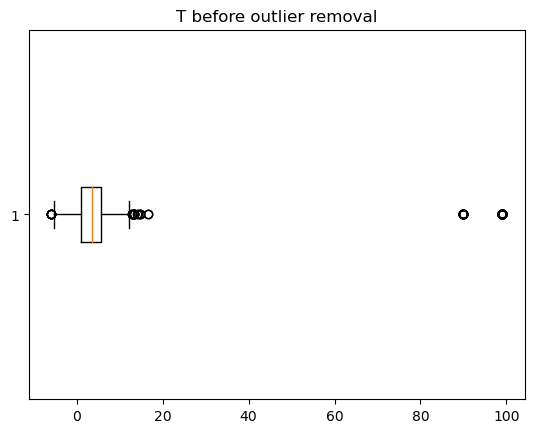

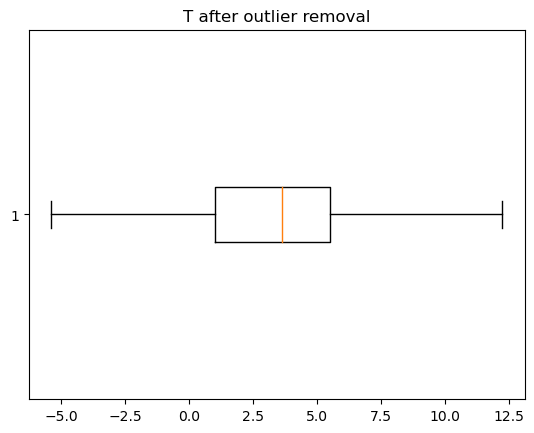

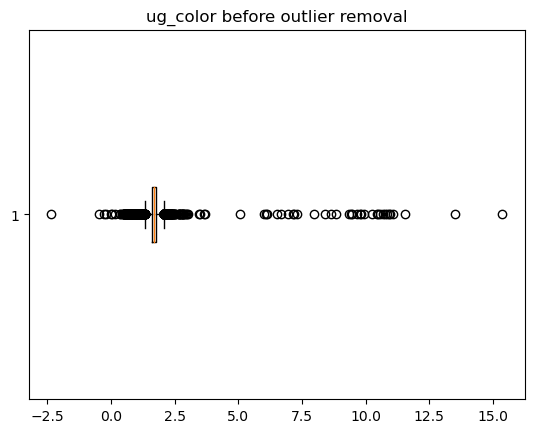

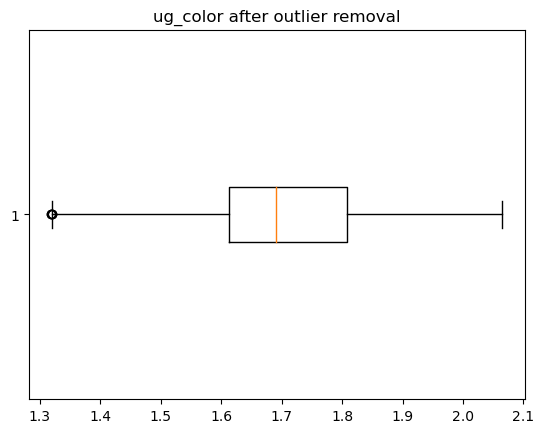

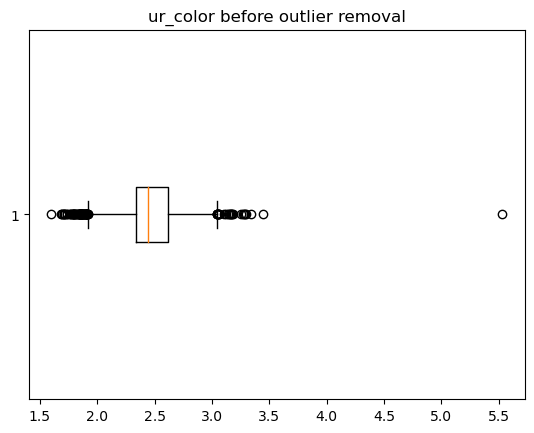

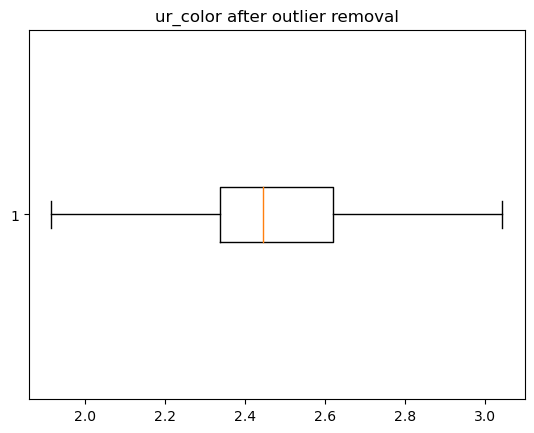

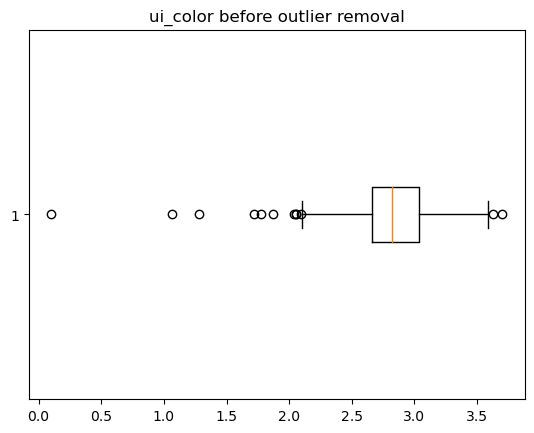

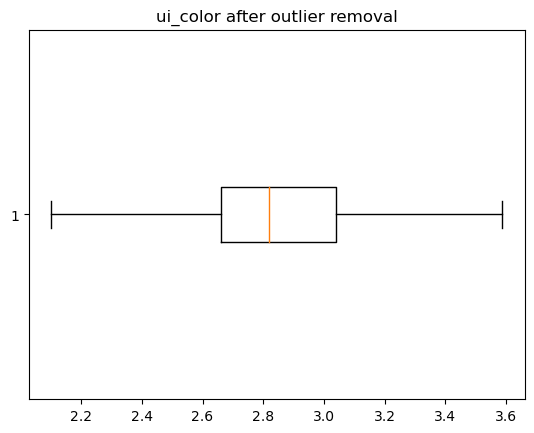

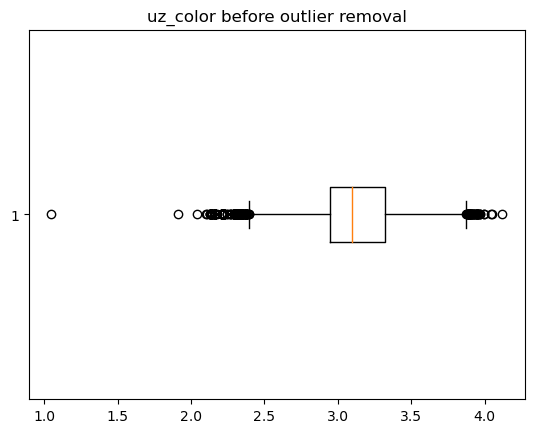

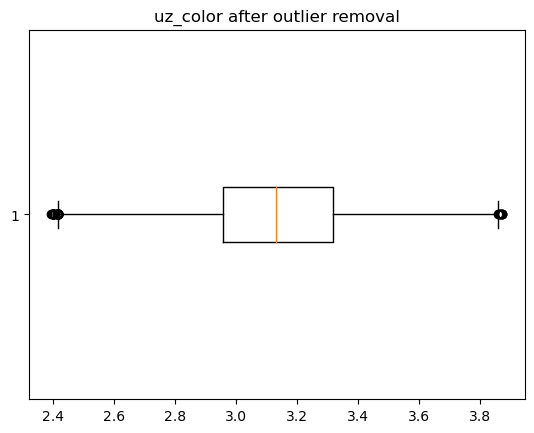

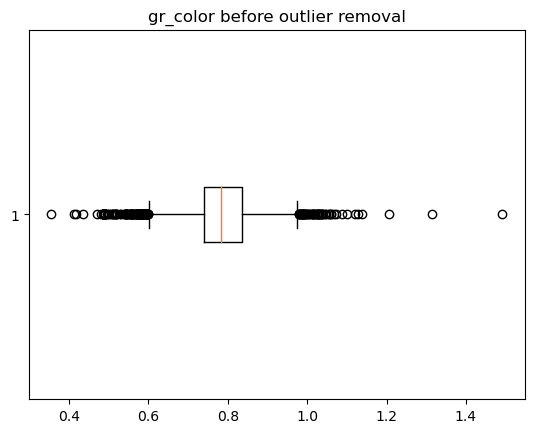

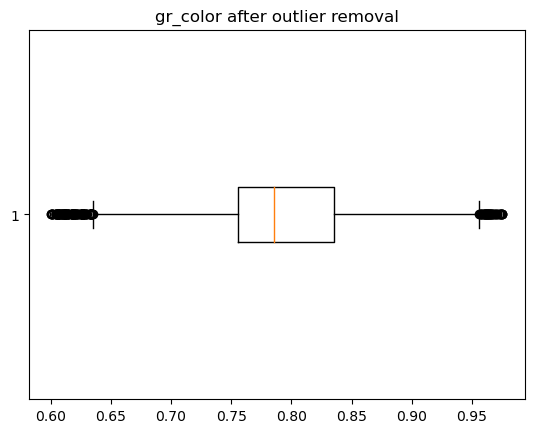

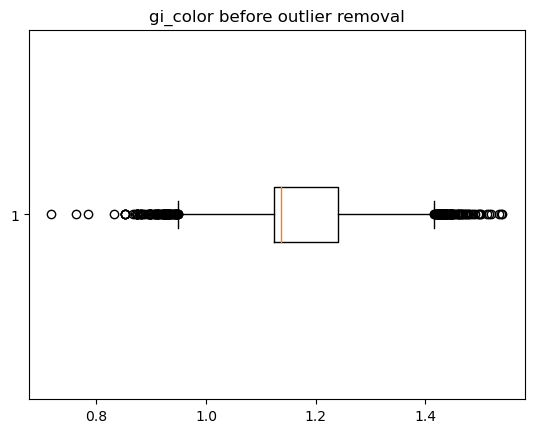

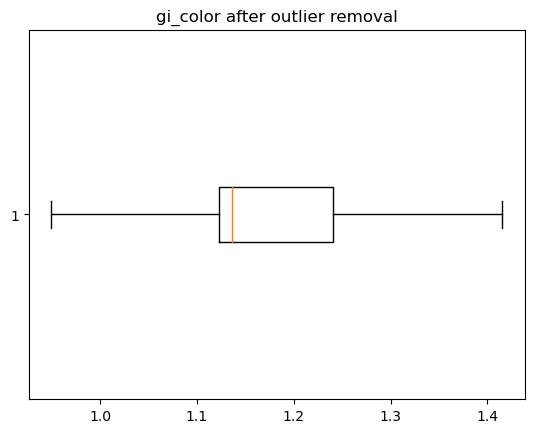

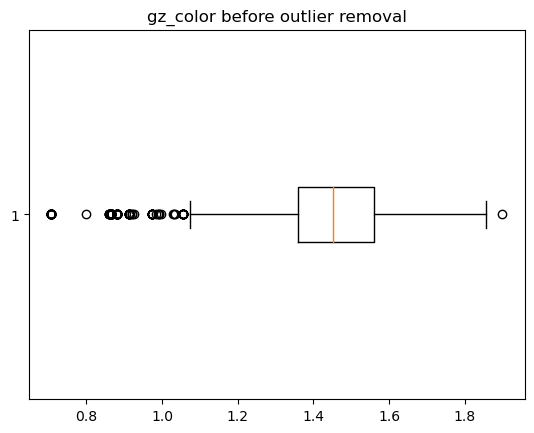

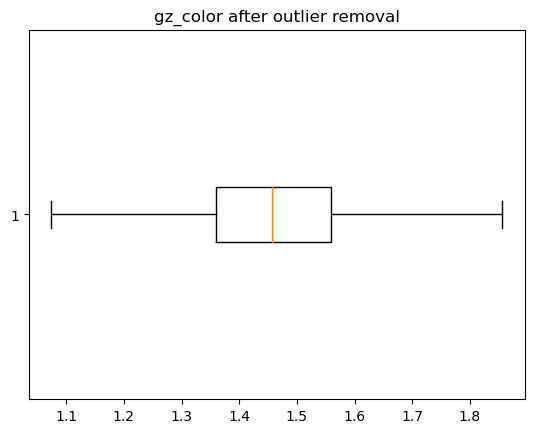

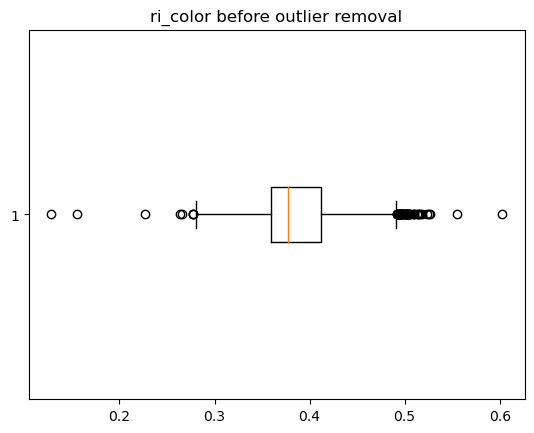

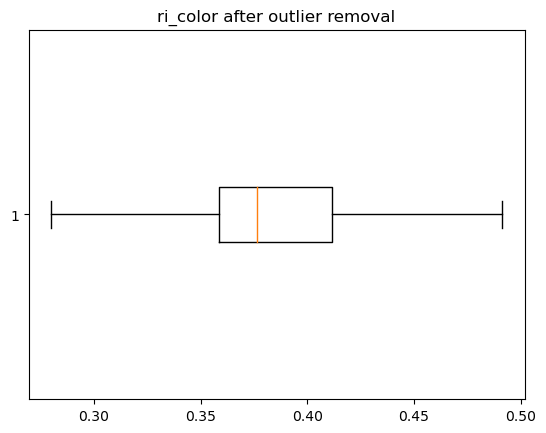

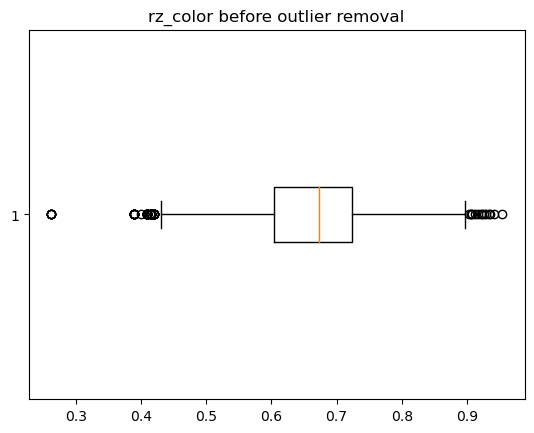

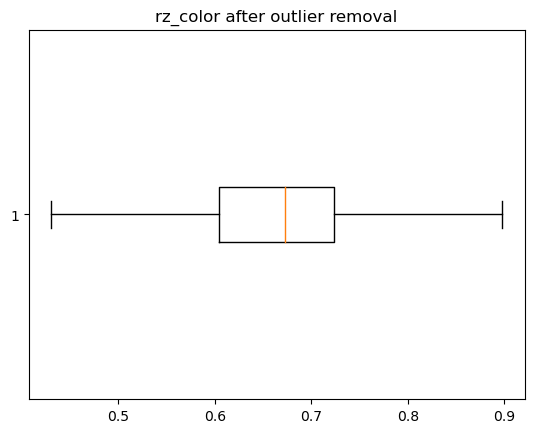

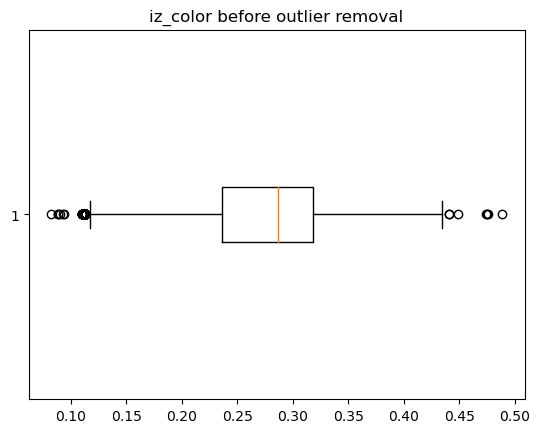

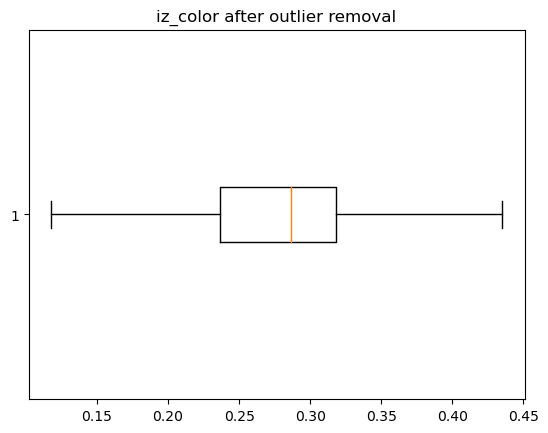

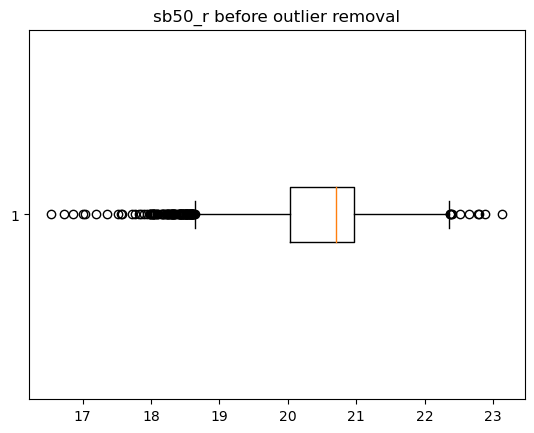

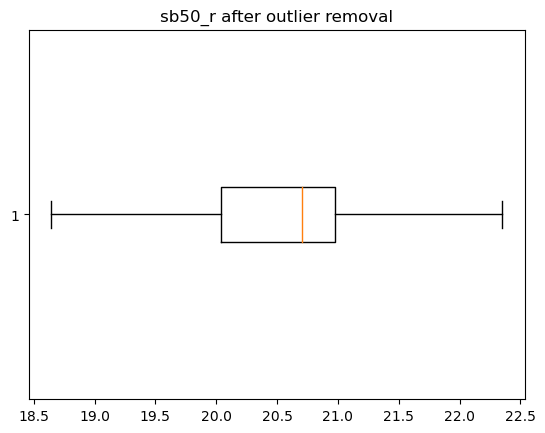

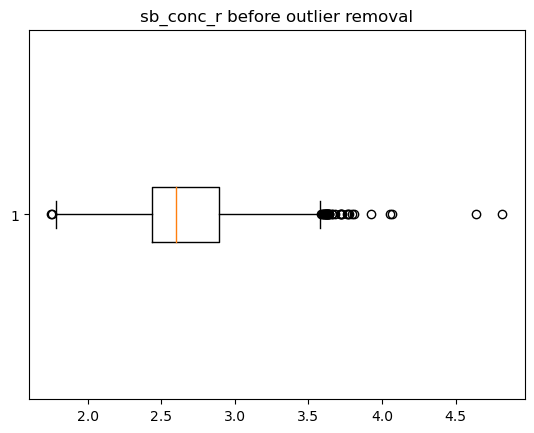

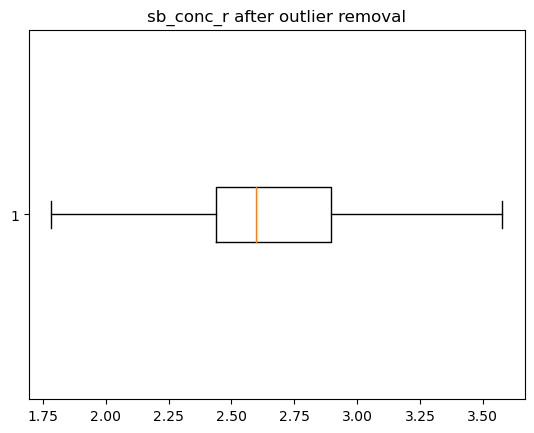

In [6]:
OUT_COLS = ['T', 'ug_color', 'ur_color', 'ui_color', 'uz_color', 'gr_color', 'gi_color', 'gz_color', 'ri_color', 'rz_color', 'iz_color', 'sb50_r', 'sb_conc_r']

for cc in OUT_COLS:
    
    nonan = np.array(data[cc])[~np.isnan(np.array(data[cc]))]
    plt.boxplot(nonan, vert=False)
    plt.title(cc+' before outlier removal')
    plt.show()

    fq = np.quantile(nonan, 0.25)
    tq = np.quantile(nonan, 0.75)
    iqr = tq - fq
    ubound = tq + 1.5*iqr
    lbound = fq - 1.5*iqr

    data = data[ data[cc]<ubound ]
    data = data[ data[cc]>lbound ]

    nonan = np.array(data[cc])[~np.isnan(np.array(data[cc]))]
    plt.boxplot(nonan, vert=False)
    plt.title(cc+' after outlier removal')
    plt.show()

## drop a bunch of stuff

In [7]:
# data.dropna(inplace=True)

## visualize

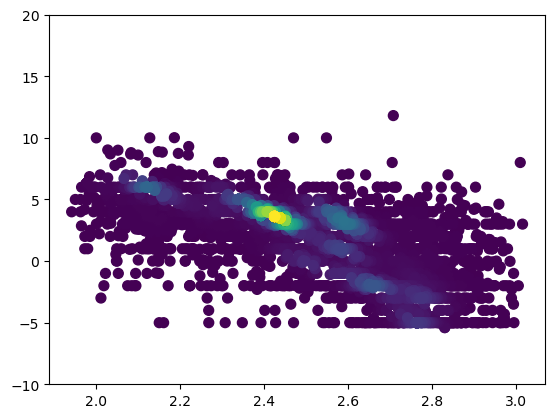

In [8]:
x = data['ur_color'].to_numpy()
y = data['T'].to_numpy()

xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

fig, ax = plt.subplots()
ax.scatter(x, y, c=z, s=50)
# ax.set_xlim([-5.,20.])
ax.set_ylim([-10.,20.])
plt.show()

In [9]:
data

,T,objID,ra,dec,imputed_brightness,sb50_r,sb_conc_r,ug_color,ur_color,ui_color,uz_color,gr_color,gi_color,gz_color,ri_color,rz_color,iz_color
0,3.000000,NaN,NaN,NaN,1,20.830039,2.509764,1.750100,2.594869,2.999993,3.318062,0.844769,1.249893,1.567962,0.405124,0.723193,0.318069
1,1.000000,1.237680e+18,0.036130,-6.374014,0,21.069490,2.590016,1.381580,2.135920,2.536660,2.880480,0.754340,1.155080,1.498900,0.400740,0.744560,0.343820
2,-4.000000,NaN,NaN,NaN,1,20.130236,3.115326,1.865598,2.753809,3.160684,3.441159,0.888211,1.295086,1.575561,0.406875,0.687350,0.280475
3,4.000000,NaN,NaN,NaN,1,21.166171,2.438623,1.777865,2.563853,2.914372,3.236208,0.785988,1.136507,1.458343,0.350519,0.672355,0.321836
7,4.000000,NaN,NaN,NaN,1,21.166171,2.438623,1.777865,2.563853,2.914372,3.236208,0.785988,1.136507,1.458343,0.350519,0.672355,0.321836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22992,4.000000,1.237673e+18,359.738531,-2.249577,0,21.120630,2.600354,1.728470,2.464680,2.832180,3.113700,0.736210,1.103710,1.385230,0.367500,0.649020,0.281520
22993,4.000000,1.237679e+18,359.745233,3.634762,0,21.084638,2.069506,1.398800,2.075860,2.444950,2.717150,0.677060,1.046150,1.318350,0.369090,0.641290,0.272200
22994,-3.800000,NaN,NaN,NaN,1,20.012812,3.104799,1.886401,2.719955,3.118552,3.396066,0.833554,1.232151,1.509665,0.398597,0.676111,0.277514
22996,3.000000,1.237680e+18,359.794703,-4.126974,0,20.504374,2.452435,1.420320,2.169720,2.561590,2.895430,0.749400,1.141270,1.475110,0.391870,0.725710,0.333840


# Make Random Forest

In [13]:
# train test split
RFXTrain, RFXTest, RFYTrain, RFYTest = train_test_split(x, y, test_size=0.2, random_state=42)
# forest of random
RandomForest = RandomForestClassifier(n_estimators=100, random_state=42)
# fit to model via training data use: RandomForest.score(RFXTest, RFYTest) to get accuracy
RandomForest.fit(RFXTrain, RFYTrain)

C:\Users\adise\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.